In [1]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score


from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()

import os

# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src.config import SUB_PATH, Config as Config  
from src.data_loader import load_data, prepare_data

cfg = Config

KAGGLE_EVAL = cfg.KAGGLE_EVAL
RANDOM_STATE = cfg.RANDOM_STATE
TASK = cfg.TASK
USE_POSTPROCESSING = cfg.USE_POSTPROCESSING
TARGET = cfg.TARGET
ID = cfg.ID
SUB_PATH = cfg.SUB_PATH
SUBMIT_PROBABILITIES = cfg.SUBMIT_PROBABILITIES
metric_name = cfg.LIB_PARAMS["rf"]["metric"]


from src.data_loader import load_data, prepare_data
from src.optuna_utils import run_optuna
from src.evaluation_utils import evaluate_model, evaluate_metric
from src.visualization_utils import plot_feature_importance, plot_learning_curve, shap_summary
from src.postprocessing_utils import optimize_postprocessing, apply_postprocessing
from src.data_splitter import DataSplitter
from src.experiment_tracker import ExperimentTracker
from sklearn.utils import compute_class_weight

# -------------------------------------------------------



Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


sys.path contains: /home/ismail/Documents/projects/ml-projects/x42


In [2]:
# -------------------------------
# Load & prepare data
# -------------------------------
X_train, X_test, y_train, y_test = load_data("encoded")
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True
)

y_train_numeric = np.array(y_train_numeric)
y_test_numeric = np.array(y_test_numeric) if y_test_numeric is not None else None

# -------------------------------
# Data splitter
# -------------------------------
splitter = DataSplitter(
    method="stratified_kfold",
    n_splits=5,
    random_state=RANDOM_STATE,
    folds_path="data/folds.npy"
)
folds = list(splitter.split(X_train, y_train_numeric, reuse_folds=True, verbose=True))


Number of classes: 3
X_train shape: (76518, 36)
X_test shape: (51012, 36)
y_train shape: (76518,)
y_test labels are not available
Test IDs available: 51012
✅ Loaded 5 folds from data/folds.npy
♻️ Reusing existing folds
--- Splitting data ---
Method: stratified_kfold
Number of splits: 5
Random seeds: [42]
Dataset size: 76518
Total folds: 5

Fold 0: Train size=61214, Val size=15304
Fold 1: Train size=61214, Val size=15304
Fold 2: Train size=61214, Val size=15304
Fold 3: Train size=61215, Val size=15303
Fold 4: Train size=61215, Val size=15303


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, log_loss
import numpy as np
import gc

num_classes = len(np.unique(y_train_numeric))
print(f"Number of classes: {num_classes}")

# -------------------------------
# Optuna objective function for RandomForest
# -------------------------------
def objective(trial):
    # RF can be slow with 1000+ trees. If your dataset is large, consider reducing n_estimators or using warm_start=True in advanced setups.
    # num_estimators = trial.suggest_int("n_estimators", 100, 1000)

    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    # max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    max_features = trial.suggest_categorical("max_features", ["sqrt", None])

    param = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500), # for small data, 100-500 is often sufficient, but we can explore up to 1500 for better performance.,
        "max_depth": trial.suggest_int('max_depth', 3, 30),
        "min_samples_split": trial.suggest_int('min_samples_split', 2, 20), # for small data, 2-10 is often sufficient, but we can explore up to 20 for better performance.
        "min_samples_leaf": trial.suggest_int('min_samples_leaf', 1, 20), # for small data, 1-5 is often sufficient, but we can explore up to 20 for better performance.,
        "max_features": trial.suggest_float('max_features', 0.3, 1.0), # in small data floats <1 are very small fractions, may cause model to underfit.  Better: trial.suggest_categorical('max_features', ['sqrt', 'log2', 1.0]) or max_features=min(1.0, X_train.shape[1]).
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        # 'class_weight': trial.suggest_categorical(
        #     'class_weight', [None, 'balanced', 'balanced_subsample']
        # ),
        # min_weight_fraction_leaf : if you want to control class-weight impact.


        "random_state": getattr(cfg, "RANDOM_STATE", 42),
        "n_jobs": -1,
        "verbose": 0
    }

    # for small data try use only those

    # n_estimators = trial.suggest_int("n_estimators", 200, 1000, log=True)
    # max_depth = trial.suggest_int("max_depth", 5, 20, log=True)
    # max_features = trial.suggest_float('max_features', 0.1, 1.0)
    # min_samples_split = trial.suggest_int('min_samples_split', 2, 50)
    # min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 25)
            # bootstrap=True,
    # max_samples = trial.suggest_float('max_samples', 0.2, 0.99)


        # # ---- Aggressive hyperparameter ranges ----
    # params = {
    #     'n_estimators': trial.suggest_int('n_estimators', 400, 1500),  # more trees
    #     'max_depth': trial.suggest_int('max_depth', 10, 50),           # allow very deep trees
    #     'min_samples_split': trial.suggest_int('min_samples_split', 2, 5),  # small splits
    #     'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 3),    # very small leaves
    #     'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 1.0]),
    #     'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
    #     'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
    #     'n_jobs': -1,
    #     'random_state': 42
    # }


    # -------------------------------
    # Class weights for imbalance
    # -------------------------------
    if cfg.TASK.lower() == "binary":
        param["class_weight"] = "balanced" if getattr(cfg, "IS_UNBALANCE", True) else None
        oof_preds = np.zeros(len(y_train_numeric))
    else:
        classes = np.unique(y_train_numeric)
        class_weights = dict(zip(classes, compute_class_weight("balanced", classes=classes, y=y_train_numeric)))
        param["class_weight"] = class_weights
        oof_preds = np.zeros((len(y_train_numeric), num_classes))

    fold_results = []
    all_fold_evals = []
    auc_scores = []
    logloss_scores = []

    for n_fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric[train_idx], y_train_numeric[valid_idx]

        clf = RandomForestClassifier(**param)
        clf.fit(X_tr, y_tr)

        # -------------------------------
        # OOF predictions
        # -------------------------------
        if cfg.TASK.lower() == "binary":
            pred_val = clf.predict_proba(X_val)[:, 1]
        else:
            pred_val = clf.predict_proba(X_val)
        oof_preds[valid_idx] = pred_val

        # -------------------------------
        # Evaluate fold
        # -------------------------------


        
        if cfg.MAXIMIZE_METRIC:  # e.g., AUC
            if cfg.TASK.lower() == "binary":
                fold_score = roc_auc_score(y_val, pred_val)
            else:
                fold_score = roc_auc_score(y_val, pred_val, multi_class="ovr")
            auc_scores.append(fold_score)
        else:
            fold_score = log_loss(y_val, pred_val)
            logloss_scores.append(fold_score)

        fold_results.append((n_fold, fold_score))
        trial.report(fold_score, step=n_fold)
 
        fold_eval = {
            "fold": n_fold,
            "y_val": y_val,
            "pred_val": pred_val,
            "score": fold_score
        }
        all_fold_evals.append(fold_eval)
        
        if trial.should_prune():
            raise optuna.TrialPruned()

        del clf, X_tr, X_val, y_tr, y_val, pred_val
        gc.collect()

    # -------------------------------
    # Compute overall OOF score
    # -------------------------------
    if cfg.MAXIMIZE_METRIC:
        if cfg.TASK.lower() == "binary":
            mean_score = roc_auc_score(y_train_numeric, oof_preds)
        else:
            mean_score = roc_auc_score(y_train_numeric, oof_preds, multi_class="ovr", average='weighted') # roc_auc_ovr_weighted (weighted by class size) → more stable than plain OVR.
    else:
        mean_score = log_loss(y_train_numeric, oof_preds)

    # -------------------------------
    # Fold report
    # -------------------------------
    metric_label = "AUC" if cfg.MAXIMIZE_METRIC else "LogLoss"
    print("\n" + "*"*50)
    for fold, score in fold_results:
        print(f"Fold {fold:>2d} | {metric_label}: {score:.5f}")
    print(f"\nMean {metric_label}: {mean_score:.5f}")
    print("*"*50 + "\n")

    # -------------------------------
    # Store trial info
    # -------------------------------
    trial.set_user_attr("fold_results", fold_results)
    trial.set_user_attr("fold_evals", all_fold_evals)
    trial.set_user_attr("mean_score", mean_score)
    trial.set_user_attr("params", param)
    trial.set_user_attr("oof_preds", oof_preds)

    return mean_score

Number of classes: 3


In [ ]:
import time
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import numpy as np
import gc
from sklearn.ensemble import RandomForestClassifier

# -------------------------------
# Run Optuna study
# -------------------------------
start = time.time()
study = run_optuna(objective, cfg)  # n_trials parameter
train_time = time.time() - start

# # -------------------------------
# # Extract CV fold results for learning curve
# # -------------------------------

# Extract OOF predictions from best trial
oof_preds = study.best_trial.user_attrs['oof_preds']

# -------------------------------
# Train final RandomForest model
# -------------------------------
best_params = study.best_params.copy()
best_params.update({
    "random_state": getattr(cfg, "RANDOM_STATE", 42),
})

print("\nTraining final RandomForest on full training data...")
final_model = RandomForestClassifier(**best_params)
final_model.fit(X_train, y_train_numeric)

# -------------------------------
# Evaluate on train set
# -------------------------------
print("---------------- Train Set --------------------")
if num_classes > 2:
    pred_train_proba = final_model.predict_proba(X_train)
    y_pred_train_class = pred_train_proba.argmax(axis=1)
else:
    pred_train_proba = final_model.predict_proba(X_train)[:, 1]
    y_pred_train_class = (pred_train_proba >= 0.5).astype(int)

metrics_df, _ = evaluate_model(y_train_numeric, pred_train_proba, task=cfg.TASK)
print(metrics_df)
print("The best mean CV score across all trials:", study.best_value)

# -------------------------------
# Evaluate OOF score
# -------------------------------
if cfg.TASK.lower() == "binary":
    oof_pred_class = (oof_preds >= 0.5).astype(int)
else:
    oof_pred_class = np.argmax(oof_preds, axis=1)

oof_score = evaluate_metric(
    y_true=y_train_numeric,
    y_input=oof_preds,  # keep as probabilities
    task=TASK,
    kaggle_eval=KAGGLE_EVAL
)
print(f"OOF {KAGGLE_EVAL}: {oof_score:.5f}")

# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test = final_model.predict_proba(X_test) if num_classes > 2 else final_model.predict_proba(X_test)[:, 1]
y_pred_class_test = (pred_test >= 0.5).astype(int) if cfg.TASK.lower() == "binary" else pred_test.argmax(axis=1)

if X_test is not None and y_test is not None:
    roc_auc_test = roc_auc_score(y_test, pred_test) if cfg.TASK.lower()=='binary' else roc_auc_score(y_test, pred_test, multi_class='ovr')
    logloss_test = log_loss(y_test, pred_test)
    accuracy_test = accuracy_score(y_test, y_pred_class_test)

    print("\n--- Test set performance ---")
    print(f"Test ROC AUC: {roc_auc_test:.5f}")
    print(f"Test Log Loss: {logloss_test:.5f}")
    print(f"Test Accuracy: {accuracy_test:.5f}")

# -------------------------------
# Optional: Post-processing
# -------------------------------
postprocessing_params = None
if USE_POSTPROCESSING:
    pp_seeds = [RANDOM_STATE, 2026, 1234, 9999]

    pp_best_params, pp_best_seed, pp_best_score = optimize_postprocessing(
        oof_preds,
        y_train_numeric,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL,
        n_trials=100,
        seeds=pp_seeds
    )

    oof_pred_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK, return_proba=True)
    oof_pred_class_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK)

    oof_acc_opt = evaluate_metric(
        y_true=y_train_numeric,
        y_input=oof_pred_opt,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL
    )
    print(f"OOF {KAGGLE_EVAL} after post-processing: {oof_acc_opt:.5f}")

    postprocessing_params = {
        "best_params": pp_best_params,
        "best_seed": pp_best_seed,
        "best_score": pp_best_score,
        "oof_pred_class_opt": oof_pred_class_opt,
        "oof_pred_opt": oof_pred_opt,
        "oof_acc_opt": oof_acc_opt,
        "kaggle_eval": KAGGLE_EVAL
    }

# -------------------------------
# Experiment Tracker
# -------------------------------
from src.experiment_tracker import ExperimentTracker

tracker = ExperimentTracker()
exp_dir = tracker.run_experiment(
    model_name="randomforest",
    final_model=final_model,
    X_train=X_train,
    y_train=y_train_numeric,
    X_test=X_test,
    best_params=best_params,
    best_score=study.best_value,
    metrics_df=metrics_df,
    train_time=train_time,
    oof_preds=oof_preds,
    task=TASK,
    postprocessing_params=postprocessing_params,
    use_postprocessing=USE_POSTPROCESSING,
    test_ids=test_ids,
    id_col=ID,
    target_col=TARGET,
    int_to_label=int_to_label,
    sample_submission_path=SUB_PATH,
    submit_proba=SUBMIT_PROBABILITIES
)

gc.collect()


**************************************************
Fold  1 | LogLoss: 0.49341
Fold  2 | LogLoss: 0.48910
Fold  3 | LogLoss: 0.49071
Fold  4 | LogLoss: 0.48809
Fold  5 | LogLoss: 0.48926

Mean LogLoss: 0.49011
**************************************************


**************************************************
Fold  1 | LogLoss: 0.49461
Fold  2 | LogLoss: 0.49860
Fold  3 | LogLoss: 0.49538
Fold  4 | LogLoss: 0.49775
Fold  5 | LogLoss: 0.49565

Mean LogLoss: 0.49640
**************************************************


**************************************************
Fold  1 | LogLoss: 0.52681
Fold  2 | LogLoss: 0.52324
Fold  3 | LogLoss: 0.52240
Fold  4 | LogLoss: 0.52428
Fold  5 | LogLoss: 0.52621

Mean LogLoss: 0.52459
**************************************************


**************************************************
Fold  1 | LogLoss: 0.51129
Fold  2 | LogLoss: 0.50546
Fold  3 | LogLoss: 0.50673
Fold  4 | LogLoss: 0.50837
Fold  5 | LogLoss: 0.50850

Mean LogLoss: 0.50807
****

0

<mark>RandomForest with class_weight="balanced" is usually better than BalancedRandomForest.</mark>

# Randomforest with RandomSearch

In [2]:
# =========================
# RandomForest Classifier
# =========================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import pandas as pd
import numpy as np
import gc


# =========================
# RandomForest model
# =========================
rf_model = RandomForestClassifier(
    n_jobs=-1,
    random_state=42
)

# =========================
# Hyperparameter grid for tuning
# =========================
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced']
}


# param_grid = {
#     'n_estimators': [300, 500, 800],
#     'max_depth': [5, 10, 15],
#     'min_samples_split': [2, 4, 6],
#     'min_samples_leaf': [1, 2, 3],
#     'max_features': ['sqrt', 0.8, 1.0],
#     'bootstrap': [True],
#     'class_weight': [None, 'balanced']
# }



# =========================
# RandomizedSearchCV
# =========================
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=50,       # number of random combinations
    scoring='accuracy',
    cv=5,
    verbose=2,
    random_state=42
)

# =========================
# Fit on training data
# =========================
random_search.fit(X_train, y_train)

# Best model
best_model = random_search.best_estimator_
print("Best Hyperparameters:", random_search.best_params_)

# =========================
# Evaluate on full training data
# =========================
y_train_pred_proba = best_model.predict_proba(X_train)[:, 1]
y_train_pred_class = best_model.predict(X_train)

roc_auc = roc_auc_score(y_train, y_train_pred_proba)
logloss = log_loss(y_train, y_train_pred_proba)
accuracy = accuracy_score(y_train, y_train_pred_class)

print("\nTraining final model on full training data...")
print(f"Train ROC AUC: {roc_auc:.5f}")
print(f"Train Log Loss: {logloss:.5f}")
print(f"Train Accuracy: {accuracy:.5f}")

# =========================
# Predict on test data
# =========================
y_pred = best_model.predict(X_test)

# =========================
# Save submission
# =========================
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': y_pred
})

submission.to_csv('submission/rf_w_RSearchCV_submission.csv', index=False)
print("Submission saved as rf_w_RSearchCV_submission.csv")

gc.collect()


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=True, class_weight=balanced, max_depth=15, max_features=1.0, min_samples_leaf=4, min_samples_split=2, n_estimators=500; total time=   0.0s
[CV] END bootstrap=True, class_weight=balanced, max_depth=15, max_features=1.0, min_samples_leaf=4, min_samples_split=2, n_estimators=500; total time=   0.0s
[CV] END bootstrap=True, class_weight=balanced, max_depth=15, max_features=1.0, min_samples_leaf=4, min_samples_split=2, n_estimators=500; total time=   0.0s
[CV] END bootstrap=True, class_weight=balanced, max_depth=15, max_features=1.0, min_samples_leaf=4, min_samples_split=2, n_estimators=500; total time=   0.0s
[CV] END bootstrap=True, class_weight=balanced, max_depth=15, max_features=1.0, min_samples_leaf=4, min_samples_split=2, n_estimators=500; total time=   0.0s
[CV] END bootstrap=True, class_weight=balanced, max_depth=15, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total ti

27

In [56]:
# Keep features above median importance
from sklearn.feature_selection import SelectFromModel


selector = SelectFromModel(final_model, threshold='median', prefit=True)

# Transform train and test sets
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

# Optional: get selected feature names
selected_features = X_train.columns[selector.get_support()]
print("Selected features:", selected_features.tolist())
print("Number of features:", X_train_sel.shape[1])


Selected features: ['owner_age', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years', 'owner_age_x_business_turnover', 'personal_income_plus_business_turnover', 'business_turnover_plus_business_age_years', 'owner_age_plus_business_turnover', 'business_turnover_x_business_age_years', 'business_expenses_plus_business_turnover', 'owner_age_x_personal_income', 'personal_income_plus_business_age_years', 'personal_income_x_business_turnover', 'owner_age_plus_personal_income', 'personal_income_x_business_age_years', 'owner_age_div_personal_income', 'business_expenses_x_business_turnover', 'business_turnover_x_business_age_months', 'owner_age_div_business_age_months', 'personal_income_x_business_expenses', 'business_turnover_plus_business_age_months', 'owner_age_plus_business_age_months', 'owner_age_plus_business_age_years', 'personal_income_plus_business_expenses', 'business_expenses_div_business_age_months', 'personal_income_x_business_age_months', 'business_exp

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, log_loss

# Use the same best params
final_model_sel = RandomForestClassifier(**best_params)

# Retrain
final_model_sel.fit(X_train_sel, y_train_numeric)

# Predict on test set
pred_test_sel = final_model_sel.predict_proba(X_test_sel)

# Evaluate
roc_auc_sel = roc_auc_score(y_test_numeric, pred_test_sel, multi_class='ovr', average='weighted')
logloss_sel = log_loss(y_test_numeric, pred_test_sel)
accuracy_sel = np.mean(np.argmax(pred_test_sel, axis=1) == y_test_numeric)

print("\n--- Test set performance after feature selection ---")
print(f"ROC AUC (OVR weighted): {roc_auc_sel:.5f}")
print(f"Log Loss:               {logloss_sel:.5f}")
print(f"Accuracy:               {accuracy_sel:.5f}")



--- Test set performance after feature selection ---
ROC AUC (OVR weighted): 0.93708
Log Loss:               0.33651
Accuracy:               0.86850


In [45]:

# -------------------------------
# Optuna study
# -------------------------------
debug = True
timeout = 60 if debug else 3600  # 1 min debug / 1 hour full

start = time.time()

sampler = optuna.samplers.TPESampler(
    n_startup_trials=30,
    multivariate=True
)

pruner = optuna.pruners.SuccessiveHalvingPruner(
    min_resource=2,
    reduction_factor=4,
    min_early_stopping_rate=1
)

study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    pruner=pruner
)

study.optimize(objective, n_trials=30, timeout=timeout)

end = time.time()

print(f"Optuna finished in {end - start:.2f} seconds")
print("Best params:", study.best_params)
print("Best CV multi_logloss:", study.best_value)

# -------------------------------
# Train final RandomForest model
# -------------------------------
best_params = study.best_params
best_params.update({
    'n_jobs': -1,
    'random_state': 2026
})

print("\nTraining final RandomForest model on full training data...")
final_model = RandomForestClassifier(**best_params)
final_model.fit(X_train, y_train_numeric)

# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test = final_model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test_numeric,
    pred_test,
    multi_class='ovr',
    average='weighted'
)

logloss = log_loss(y_test_numeric, pred_test)
accuracy = np.mean(np.argmax(pred_test, axis=1) == y_test_numeric)

print("\n--- Test set performance ---")
print(f"ROC AUC (OVR weighted): {roc_auc:.5f}")
print(f"Log Loss:           {logloss:.5f}")
print(f"Accuracy:           {accuracy:.5f}")

gc.collect()


[I 2026-01-02 22:32:23,311] A new study created in memory with name: no-name-df2e5954-4aef-40b5-a6aa-fbc20e83adee
[I 2026-01-02 22:32:59,437] Trial 0 finished with value: 0.3531860027618069 and parameters: {'n_estimators': 1336, 'max_depth': 29, 'min_samples_split': 10, 'min_samples_leaf': 16, 'max_features': 0.9084325210331317, 'bootstrap': True, 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.3531860027618069.
[I 2026-01-02 22:33:26,091] Trial 1 finished with value: 0.3095230573497754 and parameters: {'n_estimators': 1423, 'max_depth': 27, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 0.6376961547042783, 'bootstrap': True, 'class_weight': None}. Best is trial 1 with value: 0.3095230573497754.


Optuna finished in 62.78 seconds
Best params: {'n_estimators': 1423, 'max_depth': 27, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 0.6376961547042783, 'bootstrap': True, 'class_weight': None}
Best CV multi_logloss: 0.3095230573497754

Training final RandomForest model on full training data...

--- Test set performance ---
ROC AUC (OVR weighted): 0.94206
Log Loss:           0.31353
Accuracy:           0.87474


261

In [7]:
import optuna.visualization as vis



# Slice plot for individual params
vis.plot_slice(study)


In [8]:
vis.plot_param_importances(study)


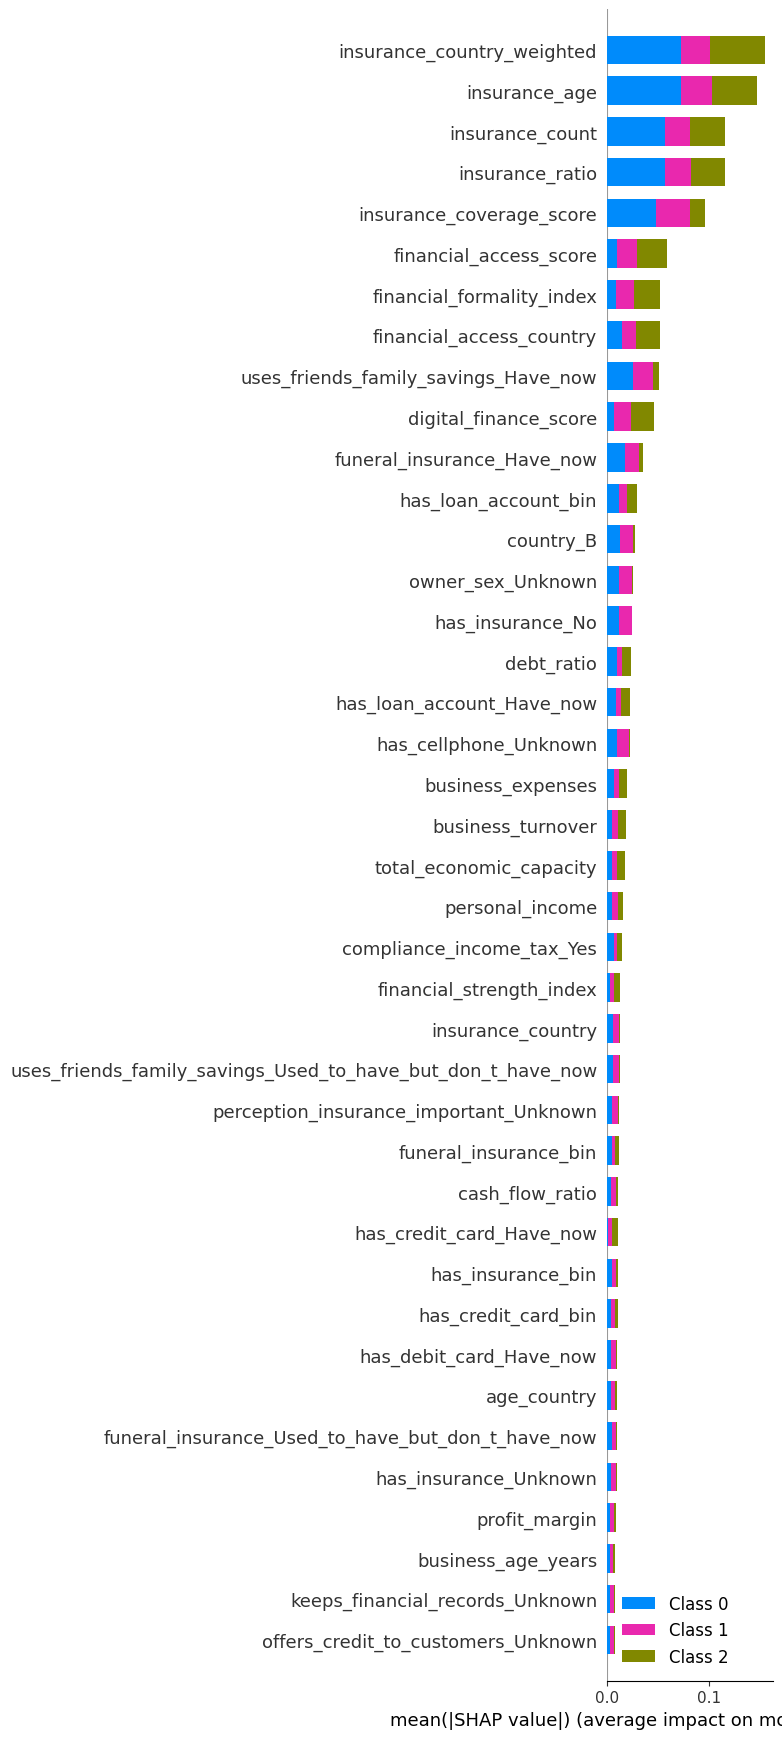

In [22]:
import shap
import numpy as np
X_shap = X_train.sample(1000, random_state=42)  # reduce if slow
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=40,
    class_names=[f"Class {i}" for i in range(len(shap_values))]
)


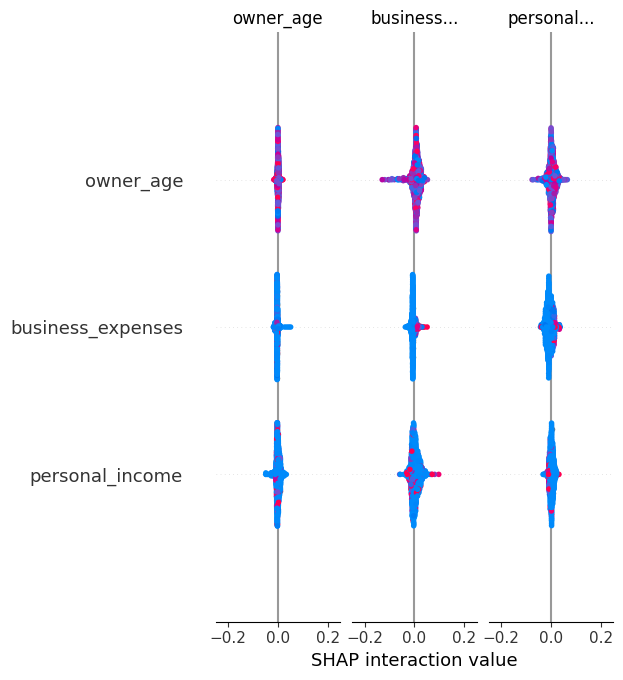

In [11]:
shap.summary_plot(
    shap_values,
    X_shap,
    class_names=[f"Class {i}" for i in range(len(shap_values))]
)


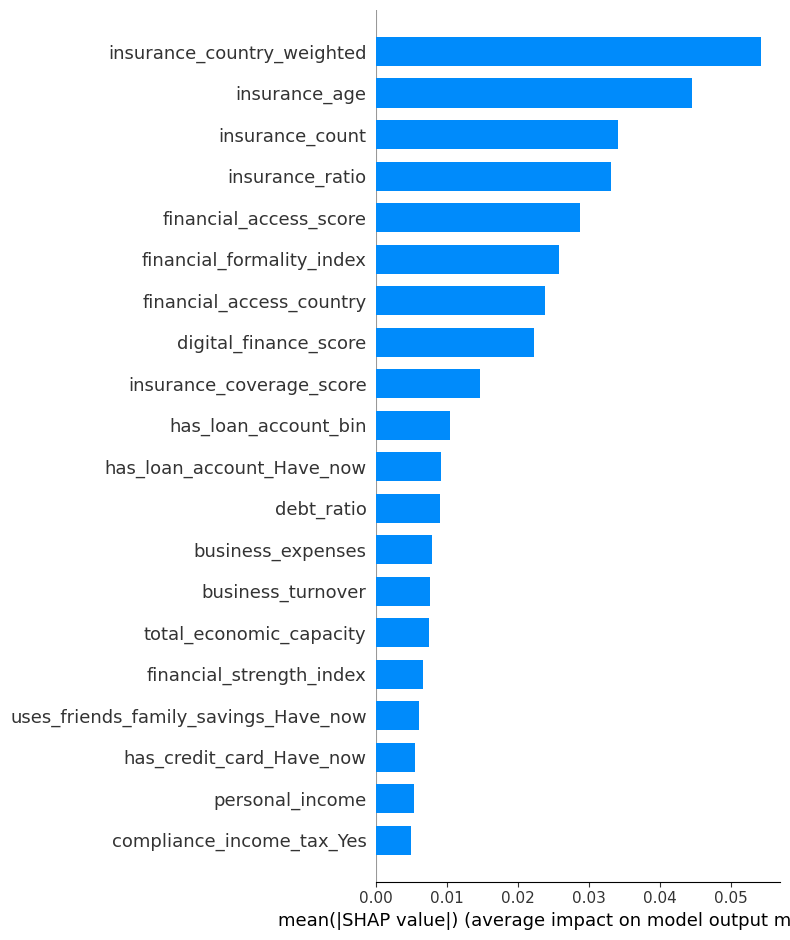

In [ ]:
def get_shap_for_class(shap_values, class_idx):
    shap_arr = np.array(shap_values)
    if shap_arr.ndim == 3:
        return shap_arr[:, :, class_idx]
    else:
        return shap_values[class_idx]

shap_c2 = get_shap_for_class(shap_values, 2)

shap.summary_plot(shap_c2, X_shap, plot_type="bar")


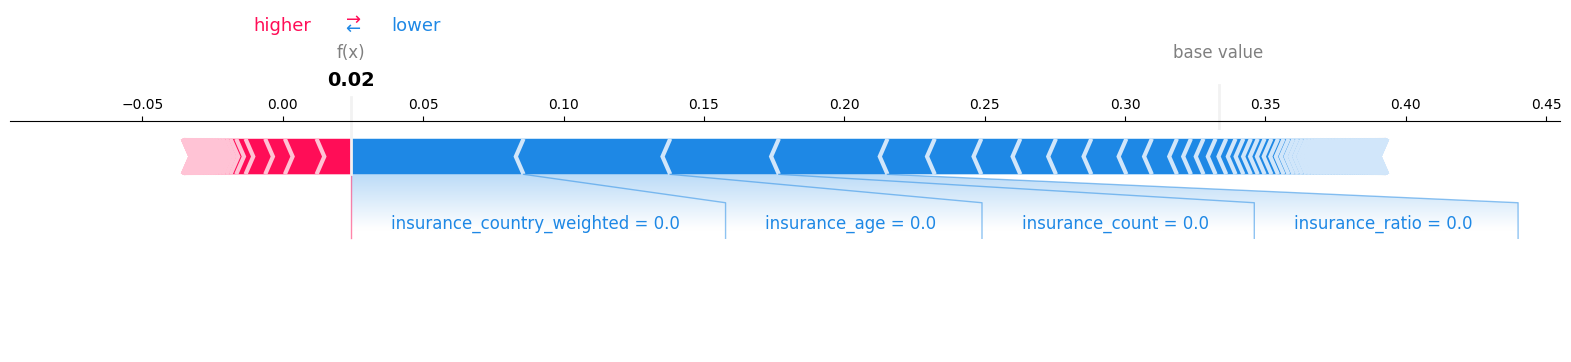

In [20]:
def shap_for_instance(shap_values, idx, class_id):
    shap_arr = np.array(shap_values)
    if shap_arr.ndim == 3:
        return shap_arr[idx, :, class_id]
    else:
        return shap_values[class_id][idx]



shap.force_plot(
    explainer.expected_value[2],
    shap_for_instance(shap_values, idx=5, class_id=2),
    X_shap.iloc[5],
    matplotlib=True
)


In [21]:
mean_abs_shap = np.mean(
    np.abs(np.stack(shap_values)),
    axis=(0, 1)
)

shap_importance = (
    pd.DataFrame({
        'feature': X_shap.columns,
        'importance': mean_abs_shap
    })
    .sort_values('importance', ascending=False)
)

shap_importance.head(15)


ValueError: All arrays must be of the same length

In [16]:
rf_importance = pd.Series(
    final_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

rf_importance.head(10)


insurance_country_weighted              0.101636
insurance_age                           0.089261
insurance_count                         0.065992
insurance_ratio                         0.065031
financial_access_score                  0.049805
financial_formality_index               0.044969
financial_access_country                0.042116
digital_finance_score                   0.034886
insurance_coverage_score                0.034414
uses_friends_family_savings_Have_now    0.022352
dtype: float64